# Config Leaderboard

Rank hyperparameter configurations by a target metric, averaged across random seeds.

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from src.utils import get_kernel_id
from src.utils.config import parse_score_metric
from src.utils.styled_tables import data_preview_styled
from src.visualization import set_themes
from IPython.display import display

set_themes()
pl.Config.set_tbl_rows(20)

print("Current kernel:", get_kernel_id())

Current kernel: 1b097d5b-af0f-40c3-8a24-ef5e5025ca55


In [2]:
run_summary_file = "wandb/summary.parquet"

# Target metric spec
# Single: "epoch/test_recall@20"
# Weighted composite: "epoch/test_recall@20:0.7 epoch/test_ndcg@20:0.3"
target_spec = "epoch/test_recall@20:0.5 epoch/test_ndcg@20:0.5"

# Filter by model(s) — empty list means no filter
model_filter = ["matrix_factorization"]

# Number of top configs to display
top_n = 20

In [3]:
experiment_runs = pl.read_parquet(run_summary_file)

if model_filter:
    experiment_runs = experiment_runs.filter(pl.col("model").is_in(model_filter))

parsed_target = parse_score_metric(target_spec)
target_metric = "target"

score_expression = sum(pl.col(m) * w for m, w in parsed_target.items())
experiment_runs = experiment_runs.with_columns(
    score_expression.list.max().alias(target_metric)
)

print(f"Loaded {len(experiment_runs):,} runs")

Loaded 3,496 runs


In [4]:
# Auto-detect config columns
EXCLUDE_COLUMNS = {
    "run_id", "run_name", "sweep_id", "model", "created_at", "config",
    "_timestamp", "_runtime", "_step", "target", "random_seed",
    "gpu_type", "cpu_count", "run_duration_second", "run_duration_minute",
    "available_locally", "summary_path", "parquet_path", "config_collapse_method",
    "tracker", "log_freq", "store_model", "evaluation_cutoffs",
}

epoch_metric_cols = {c for c in experiment_runs.columns if c.startswith("epoch/")}
config_columns = sorted(set(experiment_runs.columns) - EXCLUDE_COLUMNS - epoch_metric_cols)

# Filter out columns with only one unique value (constants across all runs)
config_columns = [
    c for c in config_columns
    if experiment_runs[c].n_unique() > 1
]

print(f"Config columns ({len(config_columns)}): {config_columns}")

leaderboard = (
    experiment_runs
    .group_by(config_columns)
    .agg(
        pl.col("target").mean().alias("avg_target"),
        pl.col("target").max().alias("best_target"),
        pl.col("target").std().alias("std_target"),
        pl.col("run_id").count().alias("num_seeds"),
    )
    .sort("avg_target", descending=True)
    .with_columns(pl.int_range(1, pl.len() + 1).alias("rank"))
    .select(["rank"] + config_columns + ["avg_target", "best_target", "std_target", "num_seeds"])
)

print(f"Unique configs in leaderboard: {len(leaderboard)}")

Config columns (5): ['embedding_dimension', 'embedding_dropout_rate', 'l1_regularization', 'l2_regularization', 'shuffle']
Unique configs in leaderboard: 1527


In [5]:
display_dataframe = leaderboard.head(top_n).to_pandas().set_index("rank")
display_dataframe.index.name = None

data_preview_styled(
    display_dataframe,
    caption=f"Top {top_n} configurations by avg {target_spec}",
)

,embedding_dimension,embedding_dropout_rate,l1_regularization,l2_regularization,shuffle,avg_target,best_target,std_target,num_seeds
1,512,0.1,1e-07,1e-07,False,0.0951409,0.0951409,nan,1
2,1024,0,1e-07,1e-07,False,0.0949969,0.0953,0.000274318,6
3,512,0,1e-07,1e-07,False,0.0948639,0.0955062,0.000452528,26
4,256,0.1,1e-07,1e-07,False,0.0946915,0.0952823,0.00083553,2
5,256,0,1e-07,1e-07,False,0.0946174,0.0956459,0.000604464,36
6,128,0.1,1e-07,1e-07,False,0.0940177,0.0940177,nan,1
7,128,0,1e-07,1e-07,False,0.0939922,0.0951336,0.000540371,24
8,128,0,1e-07,1e-07,True,0.0939223,0.0939223,nan,1
9,512,0,1e-07,1e-07,True,0.0934968,0.0934968,nan,1
10,256,0,1e-08,1e-07,False,0.0931432,0.0933895,0.000348236,2


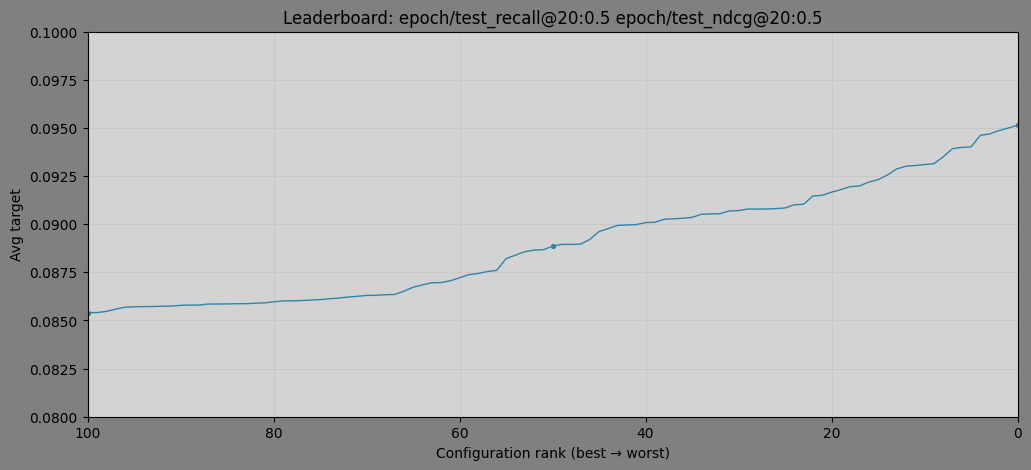

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(leaderboard["avg_target"], linewidth=1, color="#2e86ab")
plt.scatter(range(0, len(leaderboard), 50), leaderboard["avg_target"][::50], s=8, color="#2e86ab")

# set limit
plt.xlim(0, 100)   # config rank range
plt.ylim(0.08, 0.10)  # target range

plt.xlabel("Configuration rank (best → worst)")
plt.ylabel("Avg target")
plt.title(f"Leaderboard: {target_spec}")
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis()
plt.show()